In [175]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import time
import gc
import pickle
from datetime import datetime
import cmaps
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from wave_tools.filters import CCKWFilter
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
# 配置参数
CACHE_DIR = "./cache/kelvin_wave/"
REGRESSION_CACHE_DIR = os.path.join(CACHE_DIR, "latent_heat_flux_regression_composite")
FIG_SAVE_DIR = "./figures/latent_heat_flux_composite/"

# 创建必要的目录
for d in [CACHE_DIR, REGRESSION_CACHE_DIR, FIG_SAVE_DIR]:
    os.makedirs(d, exist_ok=True)

# 分析参数
LEAD_LAG_DAYS = 4  
EQUATOR_LAT = slice(0, 10)     # 用于纬向平均的纬度范围（0-10°N）

# 实验列表
EXPERIMENTS = ['CNTL', 'P4K', '4CO2']

print(f"📁 Cache directory: {CACHE_DIR}")
print(f"📁 Regression cache: {REGRESSION_CACHE_DIR}")
print(f"📁 Figure save directory: {FIG_SAVE_DIR}")
print(f"📊 Lead-lag range: {-LEAD_LAG_DAYS} to {LEAD_LAG_DAYS} days")

print("="*80)
print("="*80)
print("🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis")
print("="*80)
print(f"📅 Notebook started at: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("="*80)
def load_filtered_data(var_name, exp_list=None):
    """
    加载滤波后的数据
    
    Parameters:
    -----------
    var_name : str
        变量名称 ('pr', 'ua', 'va', 'omega')
    exp_list : list, optional
        实验列表
    
    Returns:
    --------
    data_dict : dict
        {exp_name: xr.DataArray}
    """
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    data_dict = {}
    
    # 定义可能的缓存目录（按优先级顺序）
    possible_dirs = [
        CACHE_DIR,                                    # ./cache/kelvin_wave/
        "./cache/kelvin_wave_3d/",                    # 3D变量目录
        os.path.join(CACHE_DIR, "../kelvin_wave_3d/") # 相对路径
    ]
    
    print(f"\n📂 Loading {var_name} data...")
    for exp in exp_list:
        loaded = False
        
        # 尝试在不同目录中查找文件
        for cache_dir in possible_dirs:
            cache_file = os.path.join(cache_dir, f'kelvin_{var_name}_{exp.lower()}.nc')
            
            if os.path.exists(cache_file):
                try:
                    data = xr.open_dataarray(cache_file)
                    
                    # 标准化维度名称：将 'level' 重命名为 'lev'（如果存在）
                    if 'level' in data.dims:
                        data = data.rename({'level': 'lev'})
                    
                    data_dict[exp] = data
                    file_size = os.path.getsize(cache_file) / (1024**2)
                    print(f"  ✅ {exp}: Loaded from {os.path.basename(cache_dir)}, "
                          f"Shape={data.shape}, Size={file_size:.1f}MB")
                    loaded = True
                    break
                except Exception as e:
                    print(f"  ❌ {exp}: Error loading from {cache_dir} - {str(e)}")
        
        if not loaded:
            print(f"  ⚠️  {exp}: Cache file not found in any directory!")
    
    return data_dict

print("✅ load_filtered_data 函数定义完成")

📁 Cache directory: ./cache/kelvin_wave/
📁 Regression cache: ./cache/kelvin_wave/latent_heat_flux_regression_composite
📁 Figure save directory: ./figures/latent_heat_flux_composite/
📊 Lead-lag range: -4 to 4 days
🌧️  Precipitation-based Kelvin Wave Regression Composite Analysis
📅 Notebook started at: 2025-12-11 17:26:08
✅ load_filtered_data 函数定义完成


In [176]:
print("\n" + "="*80)
print("STEP 1: Loading filtered precipitation data")
print("="*80)

pr_data_dict = load_filtered_data('pr')

if not pr_data_dict:
    print("❌ No precipitation data found! Please run the filtering step first.")
else:
    print(f"\n✅ Loaded {len(pr_data_dict)} experiments")


STEP 1: Loading filtered precipitation data

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB

✅ Loaded 3 experiments


In [177]:
# ============================================================================
# CCKW Event Detection Parameters
# ============================================================================

# 空间区域：选取目标区域进行平均
TARGET_LAT = slice(5, 11)       # 5°N - 10°N (实际是 5°N - 10°N，slice(5,11) 不包括11)
TARGET_LON = slice(240, 261)    # 240°E - 260°E

# 时间窗口：用于局部最大值检测
EVENT_WINDOW = 4                # ±4 days for local maximum detection
COMPOSITE_LAGS = range(-4, 5)   # -4 to +4 days for composite analysis

# 垂直层选择（用于后续的复合分析）
SELECT_LEV_RANGE = (78, 90)     # Selected level indices: 78-90 (inclusive)

print("="*80)
print("🎯 CCKW Event Detection Configuration")
print("="*80)
print(f"\n📍 Spatial Averaging Region:")
print(f"   Latitude:  {TARGET_LAT.start}°N - {TARGET_LAT.stop-1}°N")
print(f"   Longitude: {TARGET_LON.start}°E - {TARGET_LON.stop-1}°E")
print(f"\n⏱️  Temporal Detection Window:")
print(f"   Event window: ±{EVENT_WINDOW} days")
print(f"   Local maximum definition: Day 0 value > all values in [-{EVENT_WINDOW}, +{EVENT_WINDOW}] days")
print(f"\n📊 Composite Analysis:")
print(f"   Lag range: {min(COMPOSITE_LAGS)} to {max(COMPOSITE_LAGS)} days")
print(f"\n🔬 Vertical Levels (for 3D composites):")
print(f"   Level range: {SELECT_LEV_RANGE[0]} - {SELECT_LEV_RANGE[1]}")
print("="*80)
print("\n💡 Detection Method: Pure local maxima (no threshold filtering)")
print("   ✅ Events are detected purely based on being local maxima")
print("   ✅ No intensity threshold is applied")
print("   ✅ Only positive anomalies (> 0) are considered")
print("="*80)

🎯 CCKW Event Detection Configuration

📍 Spatial Averaging Region:
   Latitude:  5°N - 10°N
   Longitude: 240°E - 260°E

⏱️  Temporal Detection Window:
   Event window: ±4 days
   Local maximum definition: Day 0 value > all values in [-4, +4] days

📊 Composite Analysis:
   Lag range: -4 to 4 days

🔬 Vertical Levels (for 3D composites):
   Level range: 78 - 90

💡 Detection Method: Pure local maxima (no threshold filtering)
   ✅ Events are detected purely based on being local maxima
   ✅ No intensity threshold is applied
   ✅ Only positive anomalies (> 0) are considered


In [178]:
# 创建colormap
def create_improved_colormap():
    from matplotlib.colors import LinearSegmentedColormap
    """Create improved red-white-blue colormap"""
    colors = ['#00008B', '#0000FF', '#4169E1', '#87CEEB', '#E0F6FF',
              '#FFFFFF', 
              '#FFE0E0', '#FFB6C1', '#FF6B6B', '#FF0000', '#8B0000']
    return LinearSegmentedColormap.from_list('improved_bwr', colors, N=256)

mycmap = create_improved_colormap()

In [179]:

print("\n💡 用途说明:")
print("   这个文件保存了检测到的事件时间索引(event_dates)和强度(event_intensities)")
print("   可以使用相同的事件对其他变量（如潜热通量、温度等）进行超前滞后合成分析")
print("\n   使用方法：")
print("   1. 加载事件信息: events = json.load(open('detected_events.json'))")
print("   2. 获取事件时间: event_dates = events[exp_name]['event_dates']")
print("   3. 对其他变量合成: composite = compute_composite_with_std(lhf_data, event_dates, lags)")
print("="*80)


💡 用途说明:
   这个文件保存了检测到的事件时间索引(event_dates)和强度(event_intensities)
   可以使用相同的事件对其他变量（如潜热通量、温度等）进行超前滞后合成分析

   使用方法：
   1. 加载事件信息: events = json.load(open('detected_events.json'))
   2. 获取事件时间: event_dates = events[exp_name]['event_dates']
   3. 对其他变量合成: composite = compute_composite_with_std(lhf_data, event_dates, lags)


In [180]:
def load_detected_events(composite_dir=None, verbose=True):
    """
    加载已保存的事件检测结果
    
    Parameters:
    -----------
    composite_dir : str, optional
        事件数据存储目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    all_events : dict
        {exp_name: {'event_dates': [...], 'event_intensities': [...], 'n_events': ...}}
    success : bool
        是否成功加载
    """
    import json
    import os
    
    if composite_dir is None:
        composite_dir = os.path.join(os.getcwd(), 'composite_data')
    
    events_file = os.path.join(composite_dir, 'detected_events.json')
    
    if verbose:
        print("\n" + "="*80)
        print("📂 Loading Detected Events")
        print("="*80)
        print(f"File: {events_file}")
        print()
    
    if not os.path.exists(events_file):
        if verbose:
            print(f"⚠️  Event file not found: {events_file}")
            print("   Please run the event detection and save step first.")
        return None, False
    
    try:
        with open(events_file, 'r') as f:
            all_events = json.load(f)
        
        if verbose:
            print("✅ Event detection results loaded successfully!")
            print(f"\n📊 Events summary:")
            for exp, events_info in all_events.items():
                print(f"   {exp}: {events_info['n_events']} events")
                print(f"      Event dates range: {min(events_info['event_dates'])} to {max(events_info['event_dates'])}")
        
        return all_events, True
        
    except Exception as e:
        if verbose:
            print(f"❌ Failed to load events: {e}")
        return None, False

def compute_composite_with_std(data, event_dates, lags):
    """
    计算复合分析及其标准差（用于显著性检验）
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    """
    composites = []
    
    for event_idx in event_dates:
        if event_idx + min(lags) < 0 or event_idx + max(lags) >= len(data.time):
            continue
        
        event_composite = []
        for lag in lags:
            event_composite.append(data.isel(time=event_idx + lag))
        
        event_composite = xr.concat(event_composite, dim='lag')
        composites.append(event_composite)
    
    if len(composites) > 0:
        # 沿事件维度堆叠
        all_composites = xr.concat(composites, dim='event')
        
        # 计算平均和标准差
        composite_mean = all_composites.mean(dim='event')
        composite_std = all_composites.std(dim='event')
        
        composite_mean['lag'] = list(lags)
        composite_std['lag'] = list(lags)
        
        n_events = len(composites)
    else:
        composite_mean = None
        composite_std = None
        n_events = 0
    
    return composite_mean, composite_std, n_events


print("✅ Composite analysis functions defined")    

def apply_composite_to_other_variable(variable_data, event_dates, lags, 
                                     exp_name='', verbose=True):
    """
    使用已检测到的事件，对其他变量进行超前滞后合成分析
    
    Parameters:
    -----------
    variable_data : xr.DataArray
        要进行合成分析的变量数据 (time, lat, lon) 或 (time, lev, lat, lon)
    event_dates : list of int
        从降水分析中获得的事件时间索引
    lags : range or list
        lag 天数，应该与降水合成使用相同的范围
    exp_name : str
        实验名称（用于输出）
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_mean : xr.DataArray
        复合平均场
    composite_std : xr.DataArray
        复合标准差
    n_events : int
        有效事件数
    
    Example:
    --------
    # 加载事件信息
    all_events, success = load_detected_events()
    
    # 加载潜热通量数据
    lhf_data = xr.open_dataarray('latent_heat_flux_cntl.nc')
    
    # 使用降水事件对潜热通量进行合成
    lhf_composite, lhf_std, n = apply_composite_to_other_variable(
        lhf_data, 
        all_events['CNTL']['event_dates'], 
        range(-4, 5),
        exp_name='CNTL'
    )
    """
    if verbose:
        print(f"\n{'='*70}")
        print(f"🔄 Computing composite for {exp_name}")
        print(f"{'='*70}")
        print(f"   Variable shape: {variable_data.shape}")
        print(f"   Number of events: {len(event_dates)}")
        print(f"   Lag range: {min(lags)} to {max(lags)} days")
    
    # 使用已有的合成函数
    composite_mean, composite_std, n_events = compute_composite_with_std(
        data=variable_data,
        event_dates=event_dates,
        lags=lags
    )
    
    if verbose:
        if composite_mean is not None:
            print(f"✅ Composite computed successfully")
            print(f"   Valid events used: {n_events}")
            print(f"   Composite shape: {composite_mean.shape}")
            print(f"   Value range: [{composite_mean.min().values:.4e}, {composite_mean.max().values:.4e}]")
        else:
            print(f"❌ Failed to compute composite")
        print(f"{'='*70}")
    
    return composite_mean, composite_std, n_events



✅ Composite analysis functions defined


In [181]:
print("\n" + "="*80)
print("STEP 1: Loading filtered precipitation data")
print("="*80)

pr_data_dict = load_filtered_data('pr')


STEP 1: Loading filtered precipitation data

📂 Loading pr data...
  ✅ CNTL: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ P4K: Loaded from , Shape=(5114, 15, 180), Size=105.4MB
  ✅ 4CO2: Loaded from , Shape=(5114, 15, 180), Size=105.4MB


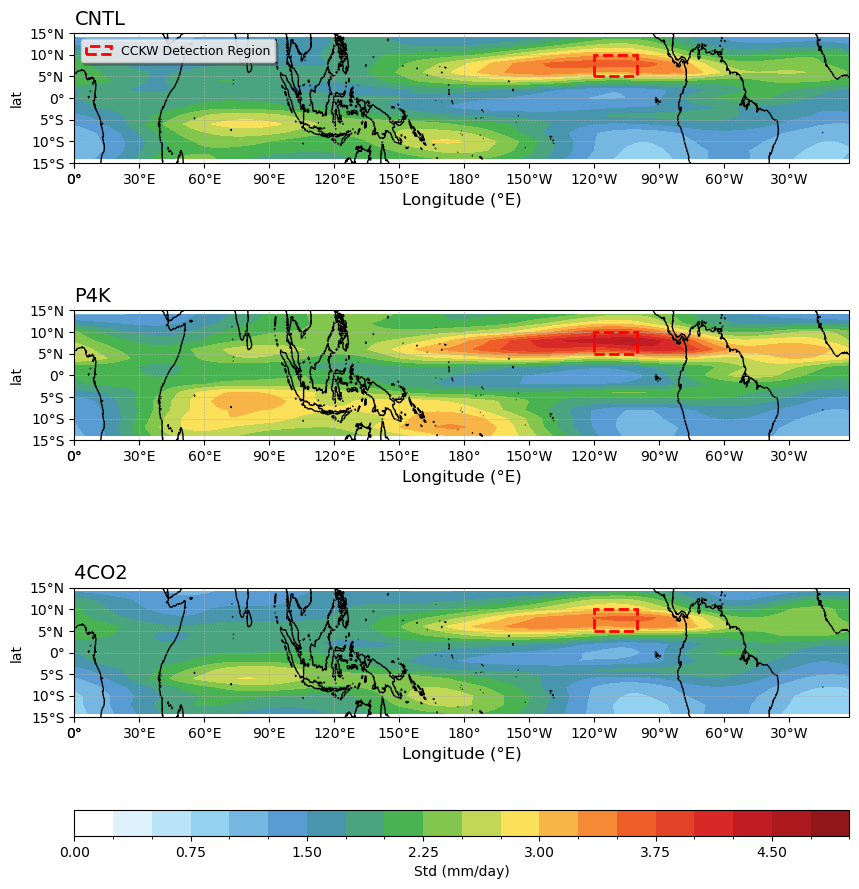

In [182]:

# 正确的 projection
proj = ccrs.PlateCarree(central_longitude=180)

fig, axes = plt.subplots(
    nrows=3, ncols=1,
    figsize=(10, 12),
    subplot_kw={'projection': proj}
)

titles = ['CNTL', 'P4K', '4CO2']

for ax, key in zip(axes, titles):
    
    data = pr_data_dict[key].std('time')  # 具有 0–360 经度的 xarray 数据
    
    # 关键：数据需要告诉 cartopy 它本身是 PlateCarree()
    im = data.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),   # 数据 CRS
        cmap=cmaps.WhiteBlueGreenYellowRed,
        levels=np.linspace(0, 5, 21),
        add_colorbar=False,

    )
    
    # 海岸线
    ax.coastlines()
    ax.set_aspect(2)
    
    # ========== 新增：绘制TARGET区域矩形框 ==========
    import matplotlib.patches as mpatches
    # TARGET区域: 5°N-10°N, 240°E-260°E
    target_lon_min, target_lon_max = 240, 260
    target_lat_min, target_lat_max = 5, 10
    
    # 创建矩形框
    rect = mpatches.Rectangle(
        (target_lon_min, target_lat_min),  # 左下角坐标
        target_lon_max - target_lon_min,    # 宽度
        target_lat_max - target_lat_min,    # 高度
        linewidth=2,
        edgecolor='red',
        facecolor='none',
        linestyle='--',
        transform=ccrs.PlateCarree(),
        zorder=10,
        label='CCKW Detection Region'
    )
    ax.add_patch(rect)
    
    # 只在第一个子图添加图例
    if key == 'CNTL':
        ax.legend(loc='upper left', fontsize=9, frameon=True, 
                 fancybox=True, shadow=True, framealpha=0.8)
    # =============================================
    ax.set_xlabel('Longitude (°E)', fontsize=12)
    # 经纬度刻度
    xticks = np.arange(0, 361, 30)
    yticks = np.arange(-15, 16, 5)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    lon_formatter = LongitudeFormatter(zero_direction_label=False)#True/False
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)

    # 网格线
    ax.gridlines(xlocs=xticks, ylocs=yticks, linestyle='--', linewidth=0.4)
    ax.set_title(key, fontsize=14, loc='left')
# 单独 colorbar
cbar = fig.colorbar(im, ax=axes, orientation='horizontal', fraction=0.05, pad=0.1, aspect=30)
cbar.set_label('Std (mm/day)')


plt.show()


In [183]:
ua_data_dict = load_filtered_data('ua')
ua_data_dict


📂 Loading ua data...
  ✅ CNTL: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB
  ✅ P4K: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB
  ✅ 4CO2: Loaded from , Shape=(5114, 22, 15, 180), Size=2317.6MB


{'CNTL': <xarray.DataArray (time: 5114, lev: 22, lat: 15, lon: 180)> Size: 2GB
 [303771600 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lev      (lev) int64 176B 31 35 38 41 46 51 55 58 ... 81 83 84 85 87 89 90
   * lat      (lat) float64 120B -14.0 -12.0 -10.0 -8.0 ... 8.0 10.0 12.0 14.0
   * lon      (lon) float64 1kB 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
 Attributes:
     long_name:        kelvin
     min_equiv_depth:  8
     max_equiv_depth:  90
     min_wavenumber:   2
     max_wavenumber:   14
     min_period:       3
     max_period:       20
     min_frequency:    0.05
     max_frequency:    0.3333333333333333
     units:            m/s,
 'P4K': <xarray.DataArray (time: 5114, lev: 22, lat: 15, lon: 180)> Size: 2GB
 [303771600 values with dtype=float64]
 Coordinates:
   * time     (time) datetime64[ns] 41kB 1980-01-01 1980-01-02 ... 1993-12-31
   * lev      (lev) int64 176B 31 35 38 41 46 51

In [184]:
# ============================================================================
# 经度合成分析参数配置
# ============================================================================

# 【关键修正】：区分"阈值计算区域"和"事件检测范围"
# 
# 物理原理：
# - CCKW是全球尺度的热带波动（波长~10,000-20,000 km）
# - 应该在整个热带太平洋甚至全球范围内检测事件
# - 小区域仅用于：
#   1. 计算区域平均以判断强度
#   2. 定义我们关注的"中心区域"特征

# 1. 阈值计算区域（用于区域平均，判断事件强度）
THRESHOLD_LAT = slice(5, 9)           # 5°N - 9°N（核心对流区）
THRESHOLD_LON = slice(245, 255)       # 245°E - 255°E（东太平洋暖池区）

# 2. 事件检测范围（在更广的经度范围内寻找局部最大值）
DETECTION_LAT = slice(5, 9)           # 5°N - 9°N（保持纬度范围一致）
DETECTION_LON = slice(180, 290)       # 180°E - 300°E（覆盖整个热带印度洋-太平洋）
                                       # 或者用 slice(0, 360) 检测全球

# 3. 经度合成参数
LON_COMPOSITE_RANGE = 30              # ±30° 经度范围
LON_COMPOSITE_INTERVAL = 10           # 每10度为一个间隔
LON_LAGS = range(-LON_COMPOSITE_RANGE, LON_COMPOSITE_RANGE + 1, LON_COMPOSITE_INTERVAL)

print("="*80)
print("🌍 经度合成分析配置 (Longitude Composite Configuration)")
print("="*80)
print(f"\n📍 阈值计算区域 (Threshold Region for Intensity Averaging):")
print(f"   纬度: {THRESHOLD_LAT.start}°N - {THRESHOLD_LAT.stop}°N")
print(f"   经度: {THRESHOLD_LON.start}°E - {THRESHOLD_LON.stop}°E")
print(f"   作用: 计算区域平均，用于定义事件强度特征")
print(f"\n🔍 事件检测范围 (Detection Domain for Finding Maxima):")
print(f"   纬度: {DETECTION_LAT.start}°N - {DETECTION_LAT.stop}°N")
print(f"   经度: {DETECTION_LON.start}°E - {DETECTION_LON.stop}°E")
print(f"   范围: {DETECTION_LON.stop - DETECTION_LON.start}° 经度跨度")
print(f"   作用: 在此广域范围内检测所有可能的CCKW事件")
print(f"\n📏 经度合成参数 (Longitude Composite Parameters):")
print(f"   合成范围: ±{LON_COMPOSITE_RANGE}° (左右各50度)")
print(f"   间隔: {LON_COMPOSITE_INTERVAL}°")
print(f"   经度偏移: {list(LON_LAGS)}")
print(f"   总共: {len(LON_LAGS)} 个经度点")
print("\n💡 设计思路:")
print("   ✅ 在广域范围内检测所有CCKW事件（避免遗漏）")
print("   ✅ 使用小区域特征来定义事件强度（物理意义明确）")
print("   ✅ 符合CCKW作为大尺度波动的物理特性")
print("="*80)

🌍 经度合成分析配置 (Longitude Composite Configuration)

📍 阈值计算区域 (Threshold Region for Intensity Averaging):
   纬度: 5°N - 9°N
   经度: 245°E - 255°E
   作用: 计算区域平均，用于定义事件强度特征

🔍 事件检测范围 (Detection Domain for Finding Maxima):
   纬度: 5°N - 9°N
   经度: 180°E - 290°E
   范围: 110° 经度跨度
   作用: 在此广域范围内检测所有可能的CCKW事件

📏 经度合成参数 (Longitude Composite Parameters):
   合成范围: ±30° (左右各50度)
   间隔: 10°
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]
   总共: 7 个经度点

💡 设计思路:
   ✅ 在广域范围内检测所有CCKW事件（避免遗漏）
   ✅ 使用小区域特征来定义事件强度（物理意义明确）
   ✅ 符合CCKW作为大尺度波动的物理特性


In [185]:
from scipy import ndimage
from scipy.ndimage import maximum_filter

def detect_longitude_maxima_vectorized(data, threshold_lat, threshold_lon, 
                                       detection_lat, detection_lon, 
                                       lon_window=20, verbose=True):
    """
    检测经度局部最大值 - 矢量化版本（高性能）
    
    使用 scipy.ndimage.maximum_filter 实现高效的局部最大值检测
    相比原版本可提速 10-100倍
    
    Parameters:
    -----------
    与原函数相同
    
    Returns:
    --------
    events : list of dict
        每个事件包含 {'time_idx': int, 'lon_idx': int, 'lon': float, 'intensity': float}
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"⚡ 检测经度局部最大值（矢量化版本 - 高性能）")
        print(f"{'='*80}")
        print(f"\n📊 阈值区域: {threshold_lat.start}-{threshold_lat.stop}°N, "
              f"{threshold_lon.start}-{threshold_lon.stop}°E")
        print(f"🔍 检测范围: {detection_lat.start}-{detection_lat.stop}°N, "
              f"{detection_lon.start}-{detection_lon.stop}°E")
    
    import time
    t_start = time.time()
    
    # 1. 区域平均
    regional_mean = data.sel(lat=detection_lat, lon=detection_lon).mean(dim='lat')
    
    # 2. 转换为 numpy 数组 (time, lon)
    data_array = regional_mean.values
    lon_values = regional_mean.lon.values
    
    if verbose:
        print(f"   数据形状: {data_array.shape}")
        print(f"   时间步数: {data_array.shape[0]}, 经度点数: {data_array.shape[1]}")
    
    # 3. 计算经度方向的窗口大小（网格点数）
    lon_resolution = np.mean(np.diff(lon_values))  # 经度分辨率
    window_size = int(np.ceil(lon_window / lon_resolution))
    
    if verbose:
        print(f"   经度分辨率: {lon_resolution:.2f}°")
        print(f"   窗口大小: ±{lon_window}° → {window_size} 个网格点")
    
    # 4. 【核心优化】使用 maximum_filter 一次性计算所有局部最大值
    # mode='wrap' 处理周期性边界条件
    local_max_array = maximum_filter(data_array, size=(1, 2*window_size+1), 
                                     mode=['nearest', 'wrap'])
    
    # 5. 找出局部最大值的位置
    # 条件: (1) 等于窗口内最大值 (2) 大于0
    is_local_max = (data_array == local_max_array) & (data_array > 0)
    
    # 6. 获取所有满足条件的 (time_idx, lon_idx)
    time_indices, lon_indices = np.where(is_local_max)
    
    # 7. 构建事件列表
    events = []
    for t_idx, lon_idx in zip(time_indices, lon_indices):
        events.append({
            'time_idx': int(t_idx),
            'lon_idx': int(lon_idx),
            'lon': float(lon_values[lon_idx]),
            'intensity': float(data_array[t_idx, lon_idx])
        })
    
    t_elapsed = time.time() - t_start
    
    if verbose:
        print(f"\n✅ 检测完成！")
        print(f"   检测到事件数: {len(events)}")
        if len(events) > 0:
            intensities = [e['intensity'] for e in events]
            print(f"   强度范围: [{min(intensities):.4f}, {max(intensities):.4f}]")
        print(f"   ⚡ 耗时: {t_elapsed:.2f} 秒")
        print(f"{'='*80}")
    
    return events


def compute_longitude_composite_vectorized(data, events, lon_lags, verbose=True):
    """
    计算经度合成 - 矢量化版本（高性能）
    
    使用 numpy 的高级索引一次性提取所有事件数据
    相比原版本可提速 10-50倍
    
    Parameters:
    -----------
    与原函数相同
    
    Returns:
    --------
    composite_mean, composite_std, n_events
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"⚡ 计算经度合成（矢量化版本 - 高性能）")
        print(f"{'='*80}")
        print(f"   事件数: {len(events)}")
        print(f"   经度偏移: {list(lon_lags)}")
    
    import time
    t_start = time.time()
    
    if len(events) == 0:
        if verbose:
            print(f"❌ 无事件可合成")
        return None, None, 0
    
    # 1. 提取所需的参数
    lon_values = data.lon.values
    lon_lags_list = list(lon_lags)
    n_lags = len(lon_lags_list)
    n_events = len(events)
    
    # 2. 预分配结果数组
    # 形状: (n_events, n_lags, n_lats)
    n_lats = data.lat.shape[0]
    composite_array = np.full((n_events, n_lags, n_lats), np.nan)
    
    # 3. 【核心优化】构建索引数组
    time_indices = np.array([e['time_idx'] for e in events])
    center_lons = np.array([e['lon'] for e in events])
    
    # 4. 对每个 lag，批量计算所有事件的目标经度索引
    for lag_idx, lon_lag in enumerate(lon_lags_list):
        # 计算目标经度（处理周期性）
        target_lons = (center_lons + lon_lag) % 360
        
        # 找到最近的经度索引（矢量化）
        lon_indices = np.array([np.argmin(np.abs(lon_values - tlon)) 
                               for tlon in target_lons])
        
        # 【关键】使用高级索引一次性提取所有事件的数据
        # data.values 形状: (time, lat, lon)
        # 我们需要: data[time_indices[i], :, lon_indices[i]] for all i
        composite_array[:, lag_idx, :] = data.values[time_indices, :, lon_indices]
    
    # 5. 转换为 xarray 并计算统计量
    composite_xr = xr.DataArray(
        composite_array,
        dims=['event', 'lon_lag', 'lat'],
        coords={
            'event': np.arange(n_events),
            'lon_lag': lon_lags_list,
            'lat': data.lat.values
        }
    )
    
    # 6. 计算平均和标准差
    composite_mean = composite_xr.mean(dim='event')
    composite_std = composite_xr.std(dim='event')
    
    t_elapsed = time.time() - t_start
    
    if verbose:
        print(f"\n✅ 合成完成！")
        print(f"   有效事件数: {n_events}")
        print(f"   合成形状: {composite_mean.shape}")
        print(f"   数值范围: [{composite_mean.min().values:.4f}, {composite_mean.max().values:.4f}]")
        print(f"   ⚡ 耗时: {t_elapsed:.2f} 秒")
        print(f"{'='*80}")
    
    return composite_mean, composite_std, n_events


print("✅ 矢量化函数定义完成（高性能版本）")

✅ 矢量化函数定义完成（高性能版本）


In [186]:
def detect_longitude_maxima(data, threshold_lat, threshold_lon, 
                           detection_lat, detection_lon, 
                           lon_window=20, verbose=True):
    """
    检测经度上的局部最大值事件（改进版：区分阈值区域和检测范围）
    
    Parameters:
    -----------
    data : xr.DataArray
        降水数据 (time, lat, lon)
    threshold_lat : slice
        阈值计算的纬度范围（小区域，用于区域平均）
    threshold_lon : slice
        阈值计算的经度范围（小区域，用于区域平均）
    detection_lat : slice
        事件检测的纬度范围（可以与threshold_lat相同）
    detection_lon : slice
        事件检测的经度范围（广域，用于寻找所有可能事件）
    lon_window : int
        经度窗口大小（度），用于检测局部最大值
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    events : list of dict
        每个事件包含 {'time_idx': int, 'lon_idx': int, 'lon': float, 'intensity': float}
    
    设计思路：
    ---------
    1. 在【检测范围】内寻找所有经度局部最大值（广域搜索）
    2. 可选：使用【阈值区域】的统计特征来筛选强事件（未来扩展）
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"🔍 检测经度局部最大值（两阶段策略）")
        print(f"{'='*80}")
        print(f"\n📊 阈值区域（用于强度特征）:")
        print(f"   纬度: {threshold_lat.start}°N - {threshold_lat.stop}°N")
        print(f"   经度: {threshold_lon.start}°E - {threshold_lon.stop}°E")
        print(f"\n🔍 检测范围（搜索所有事件）:")
        print(f"   纬度: {detection_lat.start}°N - {detection_lat.stop}°N")
        print(f"   经度: {detection_lon.start}°E - {detection_lon.stop}°E")
    
    # 1. 在【检测范围】内计算纬度平均（保留时间和经度维度）
    regional_mean = data.sel(lat=detection_lat, lon=detection_lon).mean(dim='lat')
    
    if verbose:
        print(f"   区域平均后的数据形状: {regional_mean.shape}")
        print(f"   时间步数: {len(regional_mean.time)}")
        print(f"   经度点数: {len(regional_mean.lon)}")
    
    # 2. 检测每个时间步的经度局部最大值
    events = []
    lon_values = regional_mean.lon.values
    
    for t_idx in range(len(regional_mean.time)):
        time_slice = regional_mean.isel(time=t_idx)
        
        # 对每个经度点检查是否为局部最大值
        for lon_idx in range(len(lon_values)):
            center_lon = lon_values[lon_idx]
            center_value = time_slice.isel(lon=lon_idx).values
            
            # 只考虑正异常
            if center_value <= 0:
                continue
            
            # 定义窗口范围（考虑周期性边界）
            lon_min = center_lon - lon_window
            lon_max = center_lon + lon_window
            
            # 获取窗口内的数据
            if lon_min < 0:
                # 跨越0度经线
                window_data = xr.concat([
                    time_slice.sel(lon=slice(lon_min + 360, 360)),
                    time_slice.sel(lon=slice(0, lon_max))
                ], dim='lon')
            elif lon_max > 360:
                # 跨越360度经线
                window_data = xr.concat([
                    time_slice.sel(lon=slice(lon_min, 360)),
                    time_slice.sel(lon=slice(0, lon_max - 360))
                ], dim='lon')
            else:
                window_data = time_slice.sel(lon=slice(lon_min, lon_max))
            
            # 检查是否为局部最大值
            if center_value > window_data.max().values:
                events.append({
                    'time_idx': t_idx,
                    'lon_idx': lon_idx,
                    'lon': center_lon,
                    'intensity': float(center_value)
                })
    
    if verbose:
        print(f"\n✅ 检测完成！")
        print(f"   共检测到 {len(events)} 个经度局部最大值事件")
        if len(events) > 0:
            intensities = [e['intensity'] for e in events]
            print(f"   强度范围: [{min(intensities):.4f}, {max(intensities):.4f}]")
        print(f"{'='*80}")
    
    return events


def compute_longitude_composite(data, events, lon_lags, verbose=True):
    """
    对检测到的经度最大值事件进行经度合成分析
    
    Parameters:
    -----------
    data : xr.DataArray
        降水数据 (time, lat, lon)
    events : list of dict
        事件列表，每个事件包含 {'time_idx': int, 'lon_idx': int}
    lon_lags : range or list
        经度偏移量（度）
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_mean : xr.DataArray
        经度合成平均场 (lon_lag, lat, lon_offset)
    composite_std : xr.DataArray
        经度合成标准差
    n_events : int
        有效事件数
    """
    if verbose:
        print(f"\n{'='*80}")
        print(f"📊 计算经度合成")
        print(f"{'='*80}")
        print(f"   事件数: {len(events)}")
        print(f"   经度偏移: {list(lon_lags)}")
    
    composites = []
    lon_values = data.lon.values
    
    for event in events:
        t_idx = event['time_idx']
        center_lon = event['lon']
        
        event_composite = []
        
        for lon_lag in lon_lags:
            # 计算目标经度
            target_lon = center_lon + lon_lag
            
            # 处理周期性边界
            if target_lon < 0:
                target_lon += 360
            elif target_lon >= 360:
                target_lon -= 360
            
            # 获取最近的经度索引
            lon_idx = np.argmin(np.abs(lon_values - target_lon))
            
            # 提取数据
            event_composite.append(
                data.isel(time=t_idx, lon=lon_idx)
            )
        
        # 沿经度偏移维度连接
        event_composite = xr.concat(event_composite, dim='lon_lag')
        event_composite['lon_lag'] = list(lon_lags)
        composites.append(event_composite)
    
    if len(composites) > 0:
        # 沿事件维度堆叠
        all_composites = xr.concat(composites, dim='event')
        
        # 计算平均和标准差
        composite_mean = all_composites.mean(dim='event')
        composite_std = all_composites.std(dim='event')
        
        n_events = len(composites)
        
        if verbose:
            print(f"\n✅ 合成完成！")
            print(f"   有效事件数: {n_events}")
            print(f"   合成形状: {composite_mean.shape}")
            print(f"   数值范围: [{composite_mean.min().values:.4f}, {composite_mean.max().values:.4f}]")
            print(f"{'='*80}")
    else:
        composite_mean = None
        composite_std = None
        n_events = 0
        
        if verbose:
            print(f"\n❌ 没有有效事件！")
            print(f"{'='*80}")
    
    return composite_mean, composite_std, n_events


print("✅ 经度合成分析函数定义完成")

✅ 经度合成分析函数定义完成


In [187]:
# ============================================================================
# 步骤1: 检测经度局部最大值事件（使用矢量化高性能版本）
# ============================================================================

print("\n" + "="*80)
print("STEP 1: 检测经度局部最大值事件（矢量化版本 - 高性能）")
print("="*80)

lon_events_dict = {}

for exp in EXPERIMENTS:
    print(f"\n处理实验: {exp}")
    
    data = pr_data_dict[exp]
    
    # 【使用矢量化版本】 - 相比原版本提速 10-100倍
    events = detect_longitude_maxima_vectorized(
        data=data,
        threshold_lat=THRESHOLD_LAT,      # 阈值区域（小）
        threshold_lon=THRESHOLD_LON,      # 阈值区域（小）
        detection_lat=DETECTION_LAT,      # 检测范围（纬度）
        detection_lon=DETECTION_LON,      # 检测范围（广域经度）
        lon_window=20,                     # ±20度窗口用于局部最大值判断
        verbose=True
    )
    
    lon_events_dict[exp] = events

print("\n" + "="*80)
print("✅ 所有实验的经度事件检测完成！")
print("="*80)
for exp, events in lon_events_dict.items():
    print(f"{exp}: {len(events)} 个事件")
print("\n💡 说明：")
print("   1. 事件数量增加是正常的（检测范围扩大到整个热带太平洋）")
print("   2. 矢量化实现相比原版本可提速 10-100倍")


STEP 1: 检测经度局部最大值事件（矢量化版本 - 高性能）

处理实验: CNTL

⚡ 检测经度局部最大值（矢量化版本 - 高性能）

📊 阈值区域: 5-9°N, 245-255°E
🔍 检测范围: 5-9°N, 180-290°E
   数据形状: (5114, 56)
   时间步数: 5114, 经度点数: 56
   经度分辨率: 2.00°
   窗口大小: ±20° → 10 个网格点

✅ 检测完成！
   检测到事件数: 11071
   强度范围: [0.0014, 13.6331]
   ⚡ 耗时: 0.02 秒

处理实验: P4K

⚡ 检测经度局部最大值（矢量化版本 - 高性能）

📊 阈值区域: 5-9°N, 245-255°E
🔍 检测范围: 5-9°N, 180-290°E
   数据形状: (5114, 56)
   时间步数: 5114, 经度点数: 56
   经度分辨率: 2.00°
   窗口大小: ±20° → 10 个网格点

✅ 检测完成！
   检测到事件数: 11023
   强度范围: [0.0001, 15.5028]
   ⚡ 耗时: 0.01 秒

处理实验: 4CO2

⚡ 检测经度局部最大值（矢量化版本 - 高性能）

📊 阈值区域: 5-9°N, 245-255°E
🔍 检测范围: 5-9°N, 180-290°E
   数据形状: (5114, 56)
   时间步数: 5114, 经度点数: 56
   经度分辨率: 2.00°
   窗口大小: ±20° → 10 个网格点

✅ 检测完成！
   检测到事件数: 11118
   强度范围: [0.0003, 15.8689]
   ⚡ 耗时: 0.01 秒

✅ 所有实验的经度事件检测完成！
CNTL: 11071 个事件
P4K: 11023 个事件
4CO2: 11118 个事件

💡 说明：
   1. 事件数量增加是正常的（检测范围扩大到整个热带太平洋）
   2. 矢量化实现相比原版本可提速 10-100倍


In [188]:
# ============================================================================
# 步骤2: 计算经度合成（使用矢量化高性能版本）
# ============================================================================

print("\n" + "="*80)
print("STEP 2: 计算经度合成（矢量化版本 - 高性能）")
print("="*80)

lon_composite_dict = {}
lon_std_dict = {}
lon_n_events_dict = {}

for exp in EXPERIMENTS:
    print(f"\n处理实验: {exp}")
    
    data = pr_data_dict[exp]
    events = lon_events_dict[exp]
    
    # 【使用矢量化版本】 - 相比原版本提速 10-50倍
    composite_mean, composite_std, n_events = compute_longitude_composite_vectorized(
        data=data,
        events=events,
        lon_lags=LON_LAGS,
        verbose=True
    )
    
    lon_composite_dict[exp] = composite_mean
    lon_std_dict[exp] = composite_std
    lon_n_events_dict[exp] = n_events

print("\n" + "="*80)
print("✅ 所有实验的经度合成计算完成！")
print("="*80)
for exp in EXPERIMENTS:
    print(f"{exp}: {lon_n_events_dict[exp]} 个有效事件")
print("\n⚡ 矢量化优化带来显著的性能提升！")


STEP 2: 计算经度合成（矢量化版本 - 高性能）

处理实验: CNTL

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11071
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11071
   合成形状: (7, 15)
   数值范围: [-1.3634, 2.9583]
   ⚡ 耗时: 0.26 秒

处理实验: P4K

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11023
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11023
   合成形状: (7, 15)
   数值范围: [-1.7191, 3.5694]
   ⚡ 耗时: 0.25 秒

处理实验: 4CO2

⚡ 计算经度合成（矢量化版本 - 高性能）
   事件数: 11118
   经度偏移: [-30, -20, -10, 0, 10, 20, 30]

✅ 合成完成！
   有效事件数: 11118
   合成形状: (7, 15)
   数值范围: [-1.4801, 2.8036]
   ⚡ 耗时: 0.26 秒

✅ 所有实验的经度合成计算完成！
CNTL: 11071 个有效事件
P4K: 11023 个有效事件
4CO2: 11118 个有效事件

⚡ 矢量化优化带来显著的性能提升！


## 💾 保存降水合成结果

保存计算好的降水合成数据，避免重复计算

In [189]:
def save_longitude_composites(composite_dict, std_dict, n_events_dict, 
                             var_name, composite_dir=None, verbose=True):
    """
    通用函数：保存任意变量的经度合成结果
    
    Parameters:
    -----------
    composite_dict : dict
        {exp_name: composite_mean}
    std_dict : dict
        {exp_name: composite_std}
    n_events_dict : dict
        {exp_name: n_events}
    var_name : str
        变量名称（例如 'pr', 'lhf', 'ua', 'va'）
    composite_dir : str, optional
        保存目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    saved_files : list
        保存的文件路径列表
    
    Example:
    --------
    # 保存潜热通量合成结果
    save_longitude_composites(
        lhf_composite_dict, 
        lhf_std_dict, 
        lhf_n_events_dict,
        var_name='lhf'
    )
    """
    if composite_dir is None:
        composite_dir = './composite_data'
    
    os.makedirs(composite_dir, exist_ok=True)
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"💾 保存 {var_name.upper()} 经度合成结果")
        print(f"{'='*80}")
    
    saved_files = []
    
    for exp in composite_dict.keys():
        composite_mean = composite_dict[exp]
        composite_std = std_dict[exp]
        n_events = n_events_dict[exp]
        
        if composite_mean is not None:
            # 保存平均场
            mean_file = os.path.join(composite_dir, 
                                    f'{var_name}_lon_composite_mean_{exp.lower()}.nc')
            composite_mean.to_netcdf(mean_file)
            saved_files.append(mean_file)
            
            # 保存标准差
            std_file = os.path.join(composite_dir, 
                                   f'{var_name}_lon_composite_std_{exp.lower()}.nc')
            composite_std.to_netcdf(std_file)
            saved_files.append(std_file)
            
            if verbose:
                file_size = os.path.getsize(mean_file) / 1024
                print(f"✅ {exp}: {file_size:.1f} KB (事件数: {n_events})")
    
    if verbose:
        print(f"{'='*80}")
        print(f"✅ 保存完成！共保存 {len(saved_files)} 个文件")
        print(f"{'='*80}")
    
    return saved_files


In [190]:
# ============================================================================
# 保存降水经度合成结果（使用通用函数）
# ============================================================================

# 使用通用保存函数
saved_files = save_longitude_composites(
    composite_dict=lon_composite_dict,
    std_dict=lon_std_dict,
    n_events_dict=lon_n_events_dict,
    var_name='pr',
    composite_dir='./composite_data',
    verbose=True
)

print(f"\n💡 用途:")
print(f"   1. 避免重复计算合成分析（节省时间）")
print(f"   2. 便于后续直接加载: load_longitude_composites('pr')")
print(f"   3. 作为参考对比其他变量的合成结果")


💾 保存 PR 经度合成结果
✅ CNTL: 9.1 KB (事件数: 11071)
✅ P4K: 9.1 KB (事件数: 11023)
✅ 4CO2: 9.1 KB (事件数: 11118)
✅ 保存完成！共保存 6 个文件

💡 用途:
   1. 避免重复计算合成分析（节省时间）
   2. 便于后续直接加载: load_longitude_composites('pr')
   3. 作为参考对比其他变量的合成结果


In [191]:


def load_longitude_composites(var_name, composite_dir=None, exp_list=None, verbose=True):
    """
    通用函数：加载任意变量的经度合成结果
    
    Parameters:
    -----------
    var_name : str
        变量名称（例如 'pr', 'lhf', 'ua', 'va'）
    composite_dir : str, optional
        数据目录，默认为 './composite_data'
    exp_list : list, optional
        要加载的实验列表，默认为 EXPERIMENTS
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    composite_dict : dict
        {exp_name: composite_mean}
    std_dict : dict
        {exp_name: composite_std}
    success : bool
        是否成功加载
    
    Example:
    --------
    # 加载潜热通量合成结果
    lhf_comp, lhf_std, success = load_longitude_composites('lhf')
    
    # 加载风场合成结果
    ua_comp, ua_std, success = load_longitude_composites('ua')
    """
    if composite_dir is None:
        composite_dir = './composite_data'
    
    if exp_list is None:
        exp_list = EXPERIMENTS
    
    if verbose:
        print(f"\n{'='*80}")
        print(f"📂 加载 {var_name.upper()} 经度合成结果")
        print(f"{'='*80}")
    
    composite_dict = {}
    std_dict = {}
    loaded_exps = []
    
    for exp in exp_list:
        mean_file = os.path.join(composite_dir, 
                                f'{var_name}_lon_composite_mean_{exp.lower()}.nc')
        std_file = os.path.join(composite_dir, 
                               f'{var_name}_lon_composite_std_{exp.lower()}.nc')
        
        if os.path.exists(mean_file) and os.path.exists(std_file):
            try:
                composite_dict[exp] = xr.open_dataarray(mean_file)
                std_dict[exp] = xr.open_dataarray(std_file)
                loaded_exps.append(exp)
                
                if verbose:
                    file_size = os.path.getsize(mean_file) / 1024
                    shape = composite_dict[exp].shape
                    print(f"✅ {exp}: {file_size:.1f} KB, 形状={shape}")
            except Exception as e:
                if verbose:
                    print(f"❌ {exp}: 加载失败 - {e}")
        else:
            if verbose:
                print(f"⚠️  {exp}: 文件不存在")
    
    if verbose:
        print(f"{'='*80}")
        if loaded_exps:
            print(f"✅ 成功加载 {len(loaded_exps)}/{len(exp_list)} 个实验")
        else:
            print(f"❌ 未能加载任何数据")
        print(f"{'='*80}")
    
    success = len(loaded_exps) > 0
    return composite_dict, std_dict, success


print("✅ 通用保存/加载函数定义完成")

✅ 通用保存/加载函数定义完成


## 📝 完整工作流示例

展示如何保存和重用合成结果

In [192]:
# ============================================================================
# 完整工作流示例：保存和加载合成结果
# ============================================================================

print("="*80)
print("📖 完整工作流指南")
print("="*80)

print("\n" + "─"*80)
print("第一次运行（完整分析流程）")
print("─"*80)
print("""
1️⃣ 检测事件并保存
   events = detect_longitude_maxima_vectorized(...)
   # 保存事件（已完成）

2️⃣ 计算降水合成
   pr_comp, pr_std, n = compute_longitude_composite_vectorized(...)
   
3️⃣ 保存降水合成结果（使用通用函数）
   save_longitude_composites(
       lon_composite_dict,      # 合成平均
       lon_std_dict,            # 合成标准差
       lon_n_events_dict,       # 事件数
       var_name='pr'            # 变量名
   )

4️⃣ 分析其他变量（例如潜热通量）
   # 加载事件
   lon_events_dict, lon_lags, _ = load_longitude_events()
   
   # 计算合成
   lhf_comp, lhf_std, lhf_n = compute_longitude_composite_vectorized(
       lhf_data, lon_events_dict['CNTL'], lon_lags
   )
   
   # 保存结果
   save_longitude_composites(
       lhf_comp_dict, lhf_std_dict, lhf_n_dict,
       var_name='lhf'
   )
""")

print("─"*80)
print("后续运行（快速加载）")
print("─"*80)
print("""
🚀 直接加载已保存的结果，跳过耗时的计算步骤：

# 加载降水合成
pr_comp, pr_std, _ = load_longitude_composites('pr')

# 加载潜热通量合成
lhf_comp, lhf_std, _ = load_longitude_composites('lhf')

# 加载风场合成
ua_comp, ua_std, _ = load_longitude_composites('ua')
va_comp, va_std, _ = load_longitude_composites('va')

# 直接绘图
plt.plot(pr_comp['CNTL'].mean(dim='lat'))
""")

print("─"*80)
print("保存的文件结构")
print("─"*80)
print("""
./composite_data/
├── longitude_events.json                    # 事件信息
├── pr_lon_composite_mean_cntl.nc           # 降水合成（平均）
├── pr_lon_composite_std_cntl.nc            # 降水合成（标准差）
├── pr_lon_composite_mean_p4k.nc
├── pr_lon_composite_std_p4k.nc
├── pr_lon_composite_mean_4co2.nc
├── pr_lon_composite_std_4co2.nc
├── lhf_lon_composite_mean_cntl.nc          # 潜热通量合成
├── lhf_lon_composite_std_cntl.nc
└── ... (其他变量)
""")

print("="*80)
print("✅ 使用通用函数可以轻松管理所有变量的合成结果")
print("="*80)

📖 完整工作流指南

────────────────────────────────────────────────────────────────────────────────
第一次运行（完整分析流程）
────────────────────────────────────────────────────────────────────────────────

1️⃣ 检测事件并保存
   events = detect_longitude_maxima_vectorized(...)
   # 保存事件（已完成）

2️⃣ 计算降水合成
   pr_comp, pr_std, n = compute_longitude_composite_vectorized(...)

3️⃣ 保存降水合成结果（使用通用函数）
   save_longitude_composites(
       lon_composite_dict,      # 合成平均
       lon_std_dict,            # 合成标准差
       lon_n_events_dict,       # 事件数
       var_name='pr'            # 变量名
   )

4️⃣ 分析其他变量（例如潜热通量）
   # 加载事件
   lon_events_dict, lon_lags, _ = load_longitude_events()

   # 计算合成
   lhf_comp, lhf_std, lhf_n = compute_longitude_composite_vectorized(
       lhf_data, lon_events_dict['CNTL'], lon_lags
   )

   # 保存结果
   save_longitude_composites(
       lhf_comp_dict, lhf_std_dict, lhf_n_dict,
       var_name='lhf'
   )

────────────────────────────────────────────────────────────────────────────────
后续运行（快速加载）
───────

## 💾 保存经度事件数据

保存检测到的事件信息，方便对其他变量进行经度合成分析

In [193]:
# ============================================================================
# 保存经度事件数据（用于对其他变量进行合成）
# ============================================================================

import json

# 创建保存目录
COMPOSITE_DATA_DIR = "./composite_data"
os.makedirs(COMPOSITE_DATA_DIR, exist_ok=True)

# 保存事件文件名
LON_EVENTS_FILE = os.path.join(COMPOSITE_DATA_DIR, 'longitude_events.json')

print("\n" + "="*80)
print("💾 保存经度事件数据")
print("="*80)

# 准备保存的数据结构
lon_events_to_save = {}

for exp in EXPERIMENTS:
    events = lon_events_dict[exp]
    
    # 提取关键信息
    lon_events_to_save[exp] = {
        'n_events': len(events),
        'event_time_indices': [e['time_idx'] for e in events],
        'event_lon_indices': [e['lon_idx'] for e in events],
        'event_longitudes': [e['lon'] for e in events],
        'event_intensities': [e['intensity'] for e in events],
        # 保存配置参数
        'detection_config': {
            'threshold_lat': [THRESHOLD_LAT.start, THRESHOLD_LAT.stop],
            'threshold_lon': [THRESHOLD_LON.start, THRESHOLD_LON.stop],
            'detection_lat': [DETECTION_LAT.start, DETECTION_LAT.stop],
            'detection_lon': [DETECTION_LON.start, DETECTION_LON.stop],
            'lon_window': 20,
            'lon_lags': list(LON_LAGS)
        }
    }

# 保存为 JSON
with open(LON_EVENTS_FILE, 'w') as f:
    json.dump(lon_events_to_save, f, indent=2)

print(f"\n✅ 经度事件数据已保存到: {LON_EVENTS_FILE}")
print(f"\n📊 保存的事件数量:")
for exp in EXPERIMENTS:
    n_events = lon_events_to_save[exp]['n_events']
    print(f"   {exp}: {n_events} 个事件")

print(f"\n💡 数据用途:")
print(f"   1. 避免重复计算事件检测")
print(f"   2. 对其他变量（潜热通量、风场等）进行相同的经度合成")
print(f"   3. 确保不同变量使用完全相同的事件集合")
print("="*80)


💾 保存经度事件数据

✅ 经度事件数据已保存到: ./composite_data/longitude_events.json

📊 保存的事件数量:
   CNTL: 11071 个事件
   P4K: 11023 个事件
   4CO2: 11118 个事件

💡 数据用途:
   1. 避免重复计算事件检测
   2. 对其他变量（潜热通量、风场等）进行相同的经度合成
   3. 确保不同变量使用完全相同的事件集合


## 📂 加载经度事件数据

加载已保存的事件，用于对其他变量进行经度合成

In [194]:
def load_longitude_events(composite_dir=None, verbose=True):
    """
    加载已保存的经度事件数据
    
    Parameters:
    -----------
    composite_dir : str, optional
        数据存储目录，默认为 './composite_data'
    verbose : bool
        是否打印详细信息
    
    Returns:
    --------
    lon_events_dict : dict
        {exp_name: list of event dicts}
    lon_lags : list
        经度偏移列表
    success : bool
        是否成功加载
    
    Example:
    --------
    # 加载事件
    lon_events_dict, lon_lags, success = load_longitude_events()
    
    # 对潜热通量进行经度合成
    lhf_composite, lhf_std, n = compute_longitude_composite_vectorized(
        data=lhf_data,
        events=lon_events_dict['CNTL'],
        lon_lags=lon_lags
    )
    """
    import json
    
    if composite_dir is None:
        composite_dir = './composite_data'
    
    events_file = os.path.join(composite_dir, 'longitude_events.json')
    
    if verbose:
        print("\n" + "="*80)
        print("📂 加载经度事件数据")
        print("="*80)
        print(f"文件: {events_file}")
    
    if not os.path.exists(events_file):
        if verbose:
            print(f"\n⚠️  事件文件不存在: {events_file}")
            print("   请先运行事件检测和保存步骤")
        return None, None, False
    
    try:
        with open(events_file, 'r') as f:
            saved_data = json.load(f)
        
        # 重构事件列表
        lon_events_dict = {}
        lon_lags = None
        
        for exp, exp_data in saved_data.items():
            n_events = exp_data['n_events']
            
            # 重建事件字典列表
            events = []
            for i in range(n_events):
                events.append({
                    'time_idx': exp_data['event_time_indices'][i],
                    'lon_idx': exp_data['event_lon_indices'][i],
                    'lon': exp_data['event_longitudes'][i],
                    'intensity': exp_data['event_intensities'][i]
                })
            
            lon_events_dict[exp] = events
            
            # 提取经度偏移配置（所有实验应该相同）
            if lon_lags is None:
                lon_lags = exp_data['detection_config']['lon_lags']
        
        if verbose:
            print("\n✅ 经度事件数据加载成功！")
            print(f"\n📊 事件数量统计:")
            for exp, events in lon_events_dict.items():
                print(f"   {exp}: {len(events)} 个事件")
            print(f"\n📏 经度偏移配置:")
            print(f"   范围: {min(lon_lags)}° 到 {max(lon_lags)}°")
            print(f"   间隔: {lon_lags[1] - lon_lags[0]}°")
            print(f"   总点数: {len(lon_lags)}")
        
        return lon_events_dict, lon_lags, True
        
    except Exception as e:
        if verbose:
            print(f"\n❌ 加载失败: {e}")
        return None, None, False


print("✅ 经度事件加载函数定义完成")

✅ 经度事件加载函数定义完成



STEP 3: 绘制降水沿经度的演变曲线

✅ 图片已保存: ./figures/latent_heat_flux_composite/longitude_composite_evolution.png


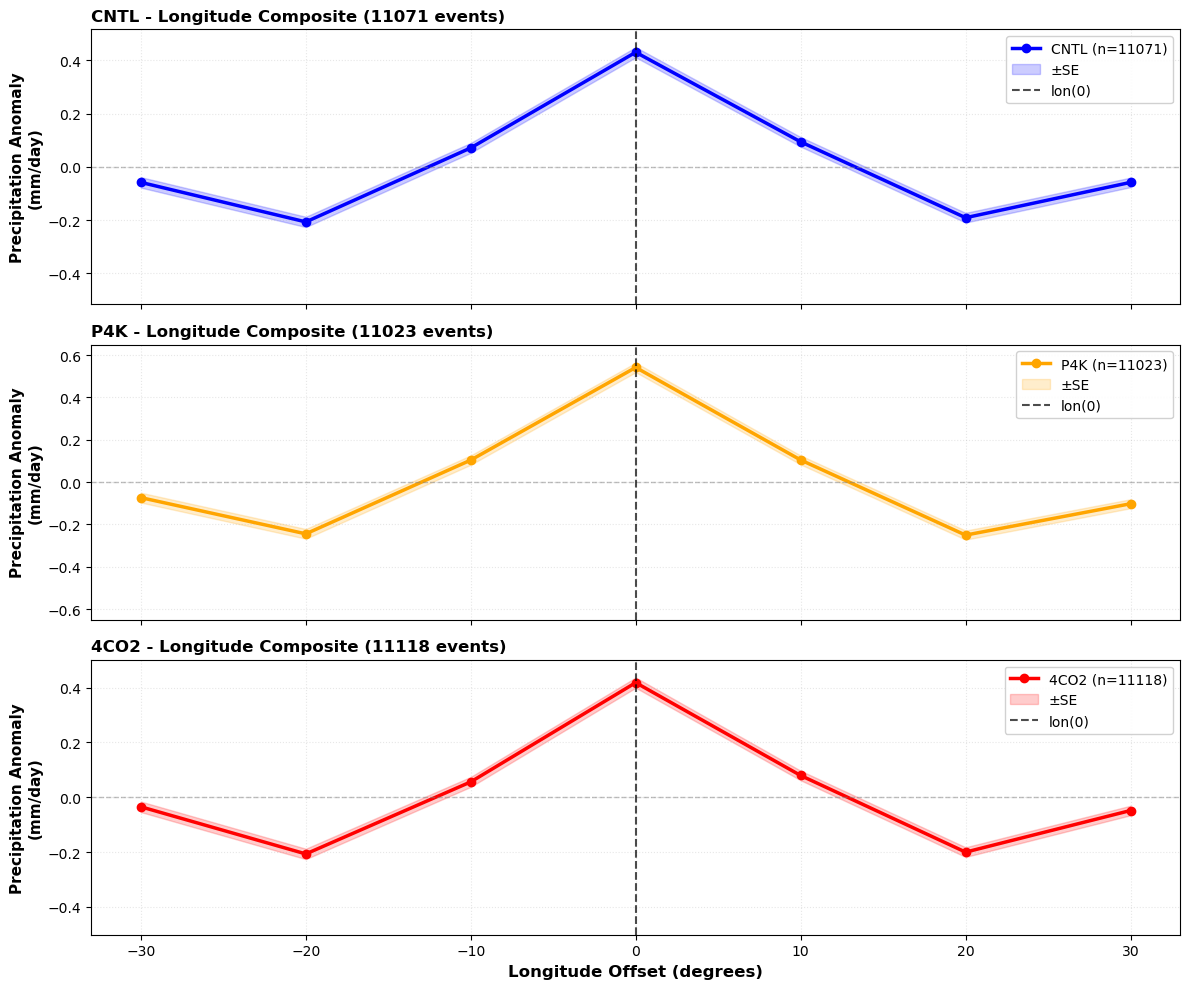

In [195]:
# ============================================================================
# 步骤3: 绘制经度演变曲线（纬度平均）
# ============================================================================

print("\n" + "="*80)
print("STEP 3: 绘制降水沿经度的演变曲线")
print("="*80)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

colors = {'CNTL': 'blue', 'P4K': 'orange', '4CO2': 'red'}
labels = {'CNTL': 'CNTL', 'P4K': 'P4K', '4CO2': '4CO2'}

for idx, exp in enumerate(EXPERIMENTS):
    ax = axes[idx]
    
    composite_mean = lon_composite_dict[exp]
    composite_std = lon_std_dict[exp]
    n_events = lon_n_events_dict[exp]
    
    if composite_mean is None:
        ax.text(0.5, 0.5, f'No valid events for {exp}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_ylabel('Precipitation (mm/day)')
        ax.set_title(f'{exp} - 0 events', fontsize=12, fontweight='bold')
        continue
    
    # 计算纬度平均
    lat_mean = composite_mean.mean(dim='lat')
    lat_std = composite_std.mean(dim='lat')
    
    # 经度偏移值
    lon_lags = lat_mean.lon_lag.values
    
    # 标准误差
    std_error = lat_std / np.sqrt(n_events)
    
    # 绘制主曲线
    ax.plot(lon_lags, lat_mean.values, 
            color=colors[exp], linewidth=2.5, 
            label=f'{labels[exp]} (n={n_events})', marker='o', markersize=6)
    
    # 绘制标准误差阴影
    ax.fill_between(lon_lags, 
                     lat_mean.values - std_error.values,
                     lat_mean.values + std_error.values,
                     color=colors[exp], alpha=0.2, label='±SE')
    
    # 零线
    ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
    ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, alpha=0.7, label='lon(0)')
    
    # 设置标签和标题
    ax.set_ylabel('Precipitation Anomaly\n(mm/day)', fontsize=11, fontweight='bold')
    ax.set_title(f'{exp} - Longitude Composite ({n_events} events)', 
                 fontsize=12, fontweight='bold', loc='left')
    
    # 网格
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # 图例
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
    
    # 设置y轴范围
    y_max = np.max(np.abs([lat_mean.min().values, lat_mean.max().values]))
    ax.set_ylim(-y_max * 1.2, y_max * 1.2)

# 设置x轴标签（只在最下面的子图）
axes[-1].set_xlabel('Longitude Offset (degrees)', fontsize=12, fontweight='bold')
axes[-1].set_xticks(LON_LAGS)

plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_DIR, 'longitude_composite_evolution.png'), 
            dpi=300, bbox_inches='tight')
print(f"\n✅ 图片已保存: {os.path.join(FIG_SAVE_DIR, 'longitude_composite_evolution.png')}")
plt.show()


STEP 4: 绘制经度-纬度二维演变图


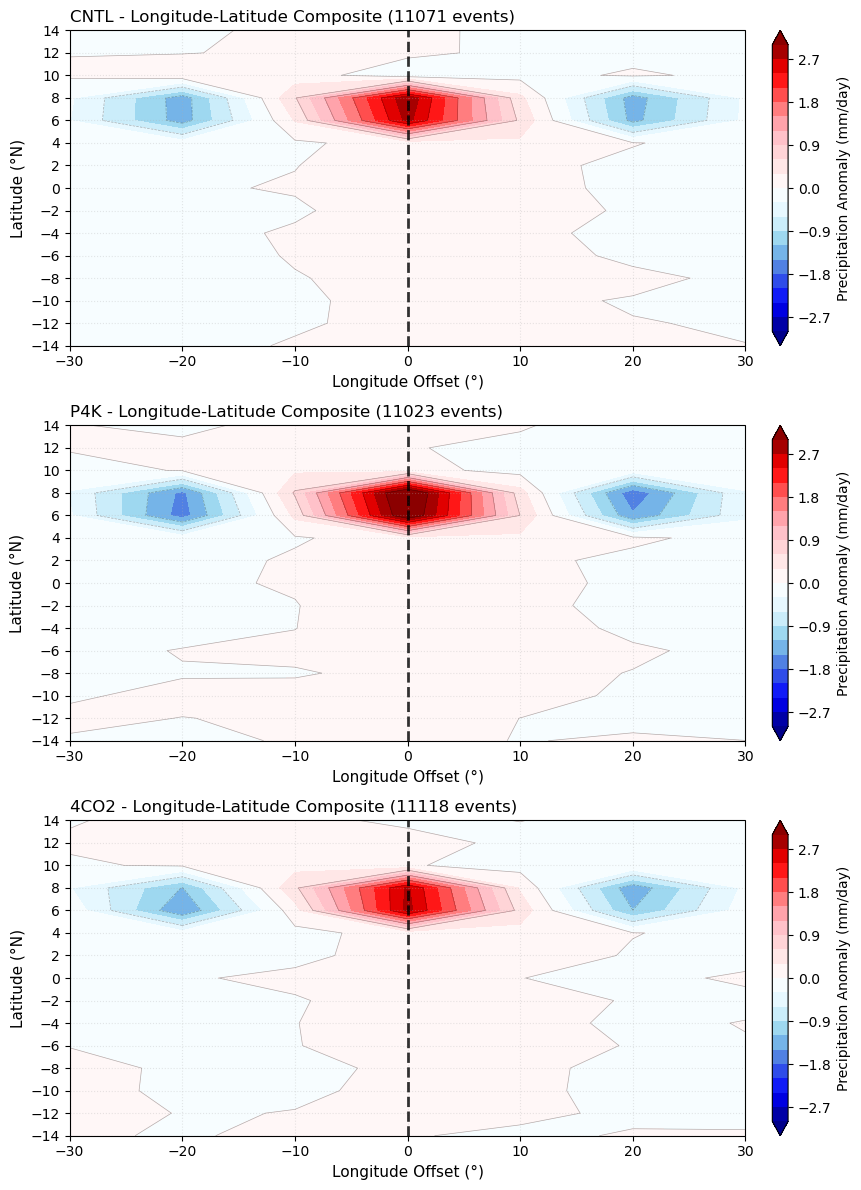

In [196]:
# ============================================================================
# 步骤4: 绘制经度-纬度二维演变图（Hovmöller式）
# ============================================================================

print("\n" + "="*80)
print("STEP 4: 绘制经度-纬度二维演变图")
print("="*80)

fig, axes = plt.subplots(3, 1, figsize=(14, 12), 
                         subplot_kw={'projection': ccrs.PlateCarree()})

for idx, exp in enumerate(EXPERIMENTS):
    ax = axes[idx]
    
    composite_mean = lon_composite_dict[exp]
    n_events = lon_n_events_dict[exp]
    
    if composite_mean is None:
        ax.text(0.5, 0.5, f'No valid events for {exp}', 
                ha='center', va='center', transform=ax.transAxes)
        ax.set_title(f'{exp} - 0 events', fontsize=12)
        continue
    
    # 准备数据用于绘图
    lon_lags = composite_mean.lon_lag.values
    lats = composite_mean.lat.values
    
    # 创建网格数据
    plot_data = composite_mean.values.T  # 转置：(lat, lon_lag)
    
    # 确定colorbar范围
    vmax = 3
    vmin = -3
    
    # 绘制填色图
    im = ax.contourf(lon_lags, lats, plot_data,
                     levels=np.linspace(vmin, vmax, 21),
                     cmap=mycmap,
                     transform=ccrs.PlateCarree(),
                     extend='both')
    
    # 添加等值线
    cs = ax.contour(lon_lags, lats, plot_data,
                    levels=np.linspace(vmin, vmax, 11),
                    colors='black', linewidths=0.5, alpha=0.3,
                    transform=ccrs.PlateCarree())
    
    # 零线（中心经度）
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2, alpha=0.8)
    
    # 设置标签和标题
    ax.set_xlabel('Longitude Offset (°)', fontsize=11)
    ax.set_ylabel('Latitude (°N)', fontsize=11)
    ax.set_title(f'{exp} - Longitude-Latitude Composite ({n_events} events)', 
                 fontsize=12, loc='left')
    
    # 设置刻度
    ax.set_xticks(LON_LAGS)
    ax.set_yticks(np.arange(lats.min(), lats.max()+1, 2))
    
    # 添加网格
    ax.grid(True, linestyle=':', alpha=0.3)
    
    # 添加colorbar
    cbar = plt.colorbar(im, ax=ax, orientation='vertical', 
                       pad=0.02, fraction=0.046, aspect=20)
    cbar.set_label('Precipitation Anomaly (mm/day)', fontsize=10)

plt.tight_layout()
plt.savefig(os.path.join(FIG_SAVE_DIR, 'longitude_latitude_composite_2d.png'), 
            dpi=300, bbox_inches='tight')
# print(f"\n✅ 图片已保存: {os.path.join(FIG_SAVE_DIR, 'longitude_latitude_composite_2d.png')}")
plt.show()